In [130]:
!pip install tensorflow

In [131]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [132]:
from tensorflow import keras

print(keras.__version__)

3.15.0


In [133]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(10, activation='relu', input_shape=(5,)),
    Dense(1, activation='sigmoid')
])

model.summary()

/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71 (284.00 B)

 Trainable params: 71 (284.00 B)

 Non-trainable params: 0 (0.00 B)

In [134]:
import sys

!{sys.executable} -m pip install pandas numpy tensorflow scikit-learn matplotlib

In [135]:
import numpy as np 
import pandas as pd

In [136]:
df=pd.read_csv('Churn_Modelling.csv')

In [137]:
df.head()
print(df.shape)

(10000, 14)


In [138]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [139]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [140]:
df.duplicated().sum()

np.int64(0)

In [141]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [142]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [143]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [144]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [145]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [146]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True,dtype=int)

In [147]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [148]:
from sklearn.model_selection import train_test_split

In [149]:
X = df.drop(columns=['Exited'])
y = df['Exited']
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [150]:
X_train.shape

(8000, 11)

In [151]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [152]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]], shape=(8000, 11))

In [153]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [154]:
model = Sequential()

model.add(Dense(11,activation='relu',input_dim =11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [155]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [156]:
model.compile(loss='binary_crossentropy',optimizer = 'Adam',metrics=['accuracy'])

In [157]:
history=model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 793us/step - accuracy: 0.7902 - loss: 0.5375 - val_accuracy: 0.7975 - val_loss: 0.4971
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 513us/step - accuracy: 0.7972 - loss: 0.4734 - val_accuracy: 0.7975 - val_loss: 0.4652
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step - accuracy: 0.8002 - loss: 0.4497 - val_accuracy: 0.8087 - val_loss: 0.4439
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step - accuracy: 0.8100 - loss: 0.4323 - val_accuracy: 0.8150 - val_loss: 0.4267
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - accuracy: 0.8195 - loss: 0.4179 - val_accuracy: 0.8181 - val_loss: 0.4125
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step - accuracy: 0.8278 - loss: 0.4042 - val_accuracy: 0.8213 - val_loss: 0.3997
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - accuracy: 0.8328 - loss: 0.3928 - val_accuracy: 0.8306 - val_loss: 0.3856
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step - accuracy: 0.8350 - loss: 0

In [158]:
model.layers[0].get_weights()

[array([[-0.03718127,  0.31898862,  0.03879721, -0.11477737,  0.14804855,
          0.32145196,  0.03845223, -0.01860141, -0.17588958,  0.03134225,
          0.09240068],
        [ 0.05818664,  0.17713536, -0.49370706, -0.14733809,  0.47970003,
         -1.0734746 ,  1.5810308 ,  0.12630466, -0.31476402,  0.42152467,
          0.41557404],
        [ 0.16466786, -0.11569908,  0.5637988 ,  0.16270356, -0.0205855 ,
         -0.25022435, -0.3430939 ,  0.09835812,  0.52353317, -0.31804067,
         -0.7941963 ],
        [-0.17201212, -0.08748496, -0.10669018,  0.80380744,  0.24979155,
          0.23212308, -0.03610138,  0.20771569, -0.60943776,  0.5570364 ,
         -0.13687113],
        [-1.3217262 , -0.28842944,  0.19410841, -0.13908969, -0.17721406,
         -0.1065145 , -0.1520658 ,  1.073681  ,  0.265716  , -0.27072793,
          0.41169345],
        [ 0.11925755,  0.25910652,  0.14145903, -0.5629102 ,  0.3959405 ,
          0.0287064 ,  0.04683683, -0.22761859, -0.43852118,  1.1703737

In [159]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step


In [160]:
y_pred=np.where(y_log>0.5,1,0)

In [161]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8625

In [162]:
import matplotlib.pyplot as plt

In [163]:
history.history

{'accuracy': [0.7901562452316284,
  0.7971875071525574,
  0.8001562356948853,
  0.8100000023841858,
  0.819531261920929,
  0.8278124928474426,
  0.832812488079071,
  0.8349999785423279,
  0.8420312404632568,
  0.848437488079071,
  0.8551562428474426,
  0.856249988079071,
  0.8581249713897705,
  0.8598437309265137,
  0.8610937595367432,
  0.8607812523841858,
  0.8592187762260437,
  0.8618749976158142,
  0.8621875047683716,
  0.8617187738418579,
  0.8643749952316284,
  0.8637499809265137,
  0.8629687428474426,
  0.8643749952316284,
  0.862500011920929,
  0.8650000095367432,
  0.8642187714576721,
  0.8651562333106995,
  0.8634374737739563,
  0.8637499809265137,
  0.8656250238418579,
  0.8645312786102295,
  0.8650000095367432,
  0.8639062643051147,
  0.8646875023841858,
  0.8656250238418579,
  0.8650000095367432,
  0.8646875023841858,
  0.8668749928474426,
  0.8662499785423279,
  0.8646875023841858,
  0.8651562333106995,
  0.8657812476158142,
  0.8656250238418579,
  0.8643749952316284,
  0

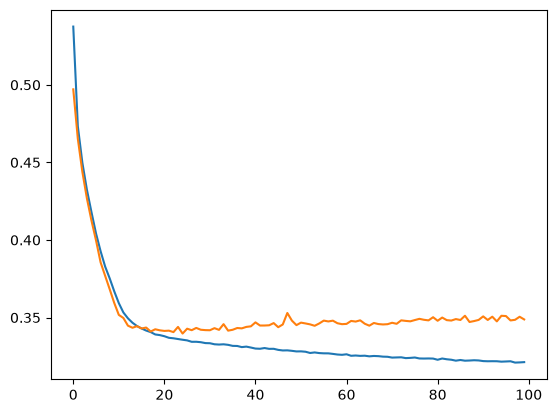

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

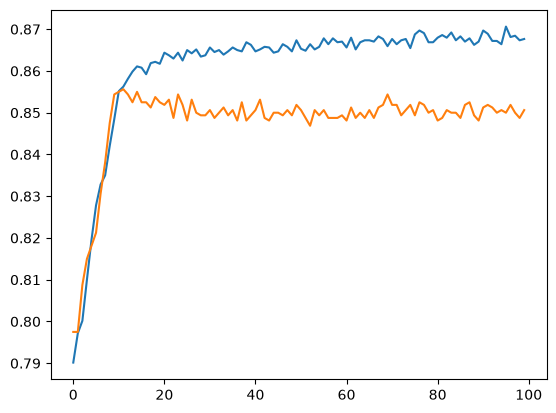

In [165]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])